In [1]:
import csv
from pathlib import Path
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy import sparse
import harmonypy as hm


In [12]:
output_path="/p2/zulab/jtian/data/SA/06_calculateConcentration/output_PCA_Harmony_2Leiden"
os.makedirs(output_path, exist_ok=True)

In [8]:
adata=sc.read_h5ad("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_PCA_Harmony_Leiden/adata_harmony_leiden_umap_res1.9.h5ad")

In [10]:
adata.obs

,condition,replicate,slice_id,sample,library_id,batch,raw_cell_id,coord_row_index_plus1,source_intensity_csv,source_coord_csv,coord_index_plus1,x,y,tic,n_met_detected,concat_library_id,cluster
ctrl1_slice0_Spot 1,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 1,2,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,2,61072.238281,10187.917969,71.940926,209,ctrl1_slice0,6
ctrl1_slice0_Spot 2,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 2,3,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,3,61092.238281,10187.917969,96.516036,225,ctrl1_slice0,6
ctrl1_slice0_Spot 3,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 3,4,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,4,61112.238281,10187.917969,130.074396,255,ctrl1_slice0,6
ctrl1_slice0_Spot 4,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 4,5,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,5,60572.238281,10167.917969,76.021944,203,ctrl1_slice0,6
ctrl1_slice0_Spot 5,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 5,6,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,6,60592.238281,10167.917969,82.957327,210,ctrl1_slice0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dn3_slice60_Spot 306207,dn,Rep3,S60,60,dn3_slice60,dn3_slice60,Spot 306207,306207,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,306207,2359.611816,5964.661621,1123.678447,258,dn3_slice60,6
dn3_slice60_Spot 306208,dn,Rep3,S60,60,dn3_slice60,dn3_slice60,Spot 306208,306208,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,306208,2379.611816,5964.661621,1013.270245,262,dn3_slice60,6
dn3_slice60_Spot 306209,dn,Rep3,S60,60,dn3_slice60,dn3_slice60,Spot 306209,306209,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,306209,2399.611816,5964.661621,676.017845,254,dn3_slice60,6
dn3_slice60_Spot 306210,dn,Rep3,S60,60,dn3_slice60,dn3_slice60,Spot 306210,306210,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,306210,2419.611816,5964.661621,657.601784,249,dn3_slice60,6


In [ ]:
for cl in adata.obs["cluster"].cat.categories:
    sub = adata[adata.obs["cluster"] == cl].copy()

    # 太小的簇通常不建议再分
    if sub.n_obs < 30:
        print(f"cluster {cl}: too small, skip")
        continue

    sc.pp.neighbors(
        sub,
        n_neighbors=15,
        use_rep="X_pca_harmony_use",
        metric="euclidean",
        random_state=0
    )

    sc.tl.leiden(sub, resolution=0.5, key_added="subcluster", random_state=0)
    sub.obs["subcluster"] = cl + "_" + sub.obs["subcluster"].astype(str)

    colname = f"subcluster_from_{cl}"
    adata.obs[colname] = pd.Series(index=adata.obs_names, dtype="object")
    adata.obs.loc[sub.obs_names, colname] = sub.obs["subcluster"].values
    adata.obs[colname] = adata.obs[colname].astype("category")

    print(colname, sub.obs["subcluster"].nunique())

In [11]:
adata.obs["subcluster"] = pd.Series(index=adata.obs_names, dtype="object")

next_cluster_id = 0  # 全局子簇编号，从0开始

for cl in adata.obs["cluster"].cat.categories:
    sub = adata[adata.obs["cluster"] == cl].copy()

    # 太小的簇通常不建议再分
    if sub.n_obs < 30:
        print(f"cluster {cl}: too small, skip")
        continue

    sc.pp.neighbors(
        sub,
        n_neighbors=15,
        use_rep="X_pca_harmony_use",
        metric="euclidean",
        random_state=0
    )

    sc.tl.leiden(sub, resolution=0.5, key_added="subcluster_local", random_state=0)

    # 取这个母簇内部的局部子簇标签
    local_cats = sorted(sub.obs["subcluster_local"].astype(str).unique())

    # 建立“局部子簇 -> 全局编号”的映射
    mapping = {}
    for lc in local_cats:
        mapping[lc] = str(next_cluster_id)
        next_cluster_id += 1

    # 写成全局子簇编号
    sub.obs["subcluster_global"] = sub.obs["subcluster_local"].astype(str).map(mapping)

    # 写回原对象
    adata.obs.loc[sub.obs_names, "subcluster"] = sub.obs["subcluster_global"].values

    print(f"parent cluster {cl}: {len(local_cats)} subclusters -> {list(mapping.values())}")

# 转成分类变量
adata.obs["subcluster"] = adata.obs["subcluster"].astype("category")

print("Total subclusters =", adata.obs["subcluster"].nunique())
print("Subcluster labels =", adata.obs["subcluster"].cat.categories.tolist())

/p1/zulab_users/jtian/anaconda3/envs/my_NewSA_py39/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/tmp/ipykernel_884038/3075615517.py:21: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(sub, resolution=0.5, key_added="subcluster_local", random_state=0)


parent cluster 0: 4 subclusters -> ['0', '1', '2', '3']
parent cluster 1: 3 subclusters -> ['4', '5', '6']
parent cluster 2: 3 subclusters -> ['7', '8', '9']
parent cluster 3: 4 subclusters -> ['10', '11', '12', '13']
parent cluster 4: 4 subclusters -> ['14', '15', '16', '17']
parent cluster 5: 3 subclusters -> ['18', '19', '20']
parent cluster 6: 2 subclusters -> ['21', '22']
parent cluster 7: 5 subclusters -> ['23', '24', '25', '26', '27']
parent cluster 8: 4 subclusters -> ['28', '29', '30', '31']
parent cluster 9: 3 subclusters -> ['32', '33', '34']
parent cluster 10: 2 subclusters -> ['35', '36']
parent cluster 11: 2 subclusters -> ['37', '38']
parent cluster 12: 3 subclusters -> ['39', '40', '41']
parent cluster 13: 3 subclusters -> ['42', '43', '44']
parent cluster 14: 4 subclusters -> ['45', '46', '47', '48']
parent cluster 15: 3 subclusters -> ['49', '50', '51']
parent cluster 16: 2 subclusters -> ['52', '53']
parent cluster 17: 3 subclusters -> ['54', '55', '56']
cluster 18: 

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not array(['#98df8a', '#98df8a', '#98df8a', ..., '#c5b0d5', '#ff7f0e',
       '#ff7f0e'], dtype=object)

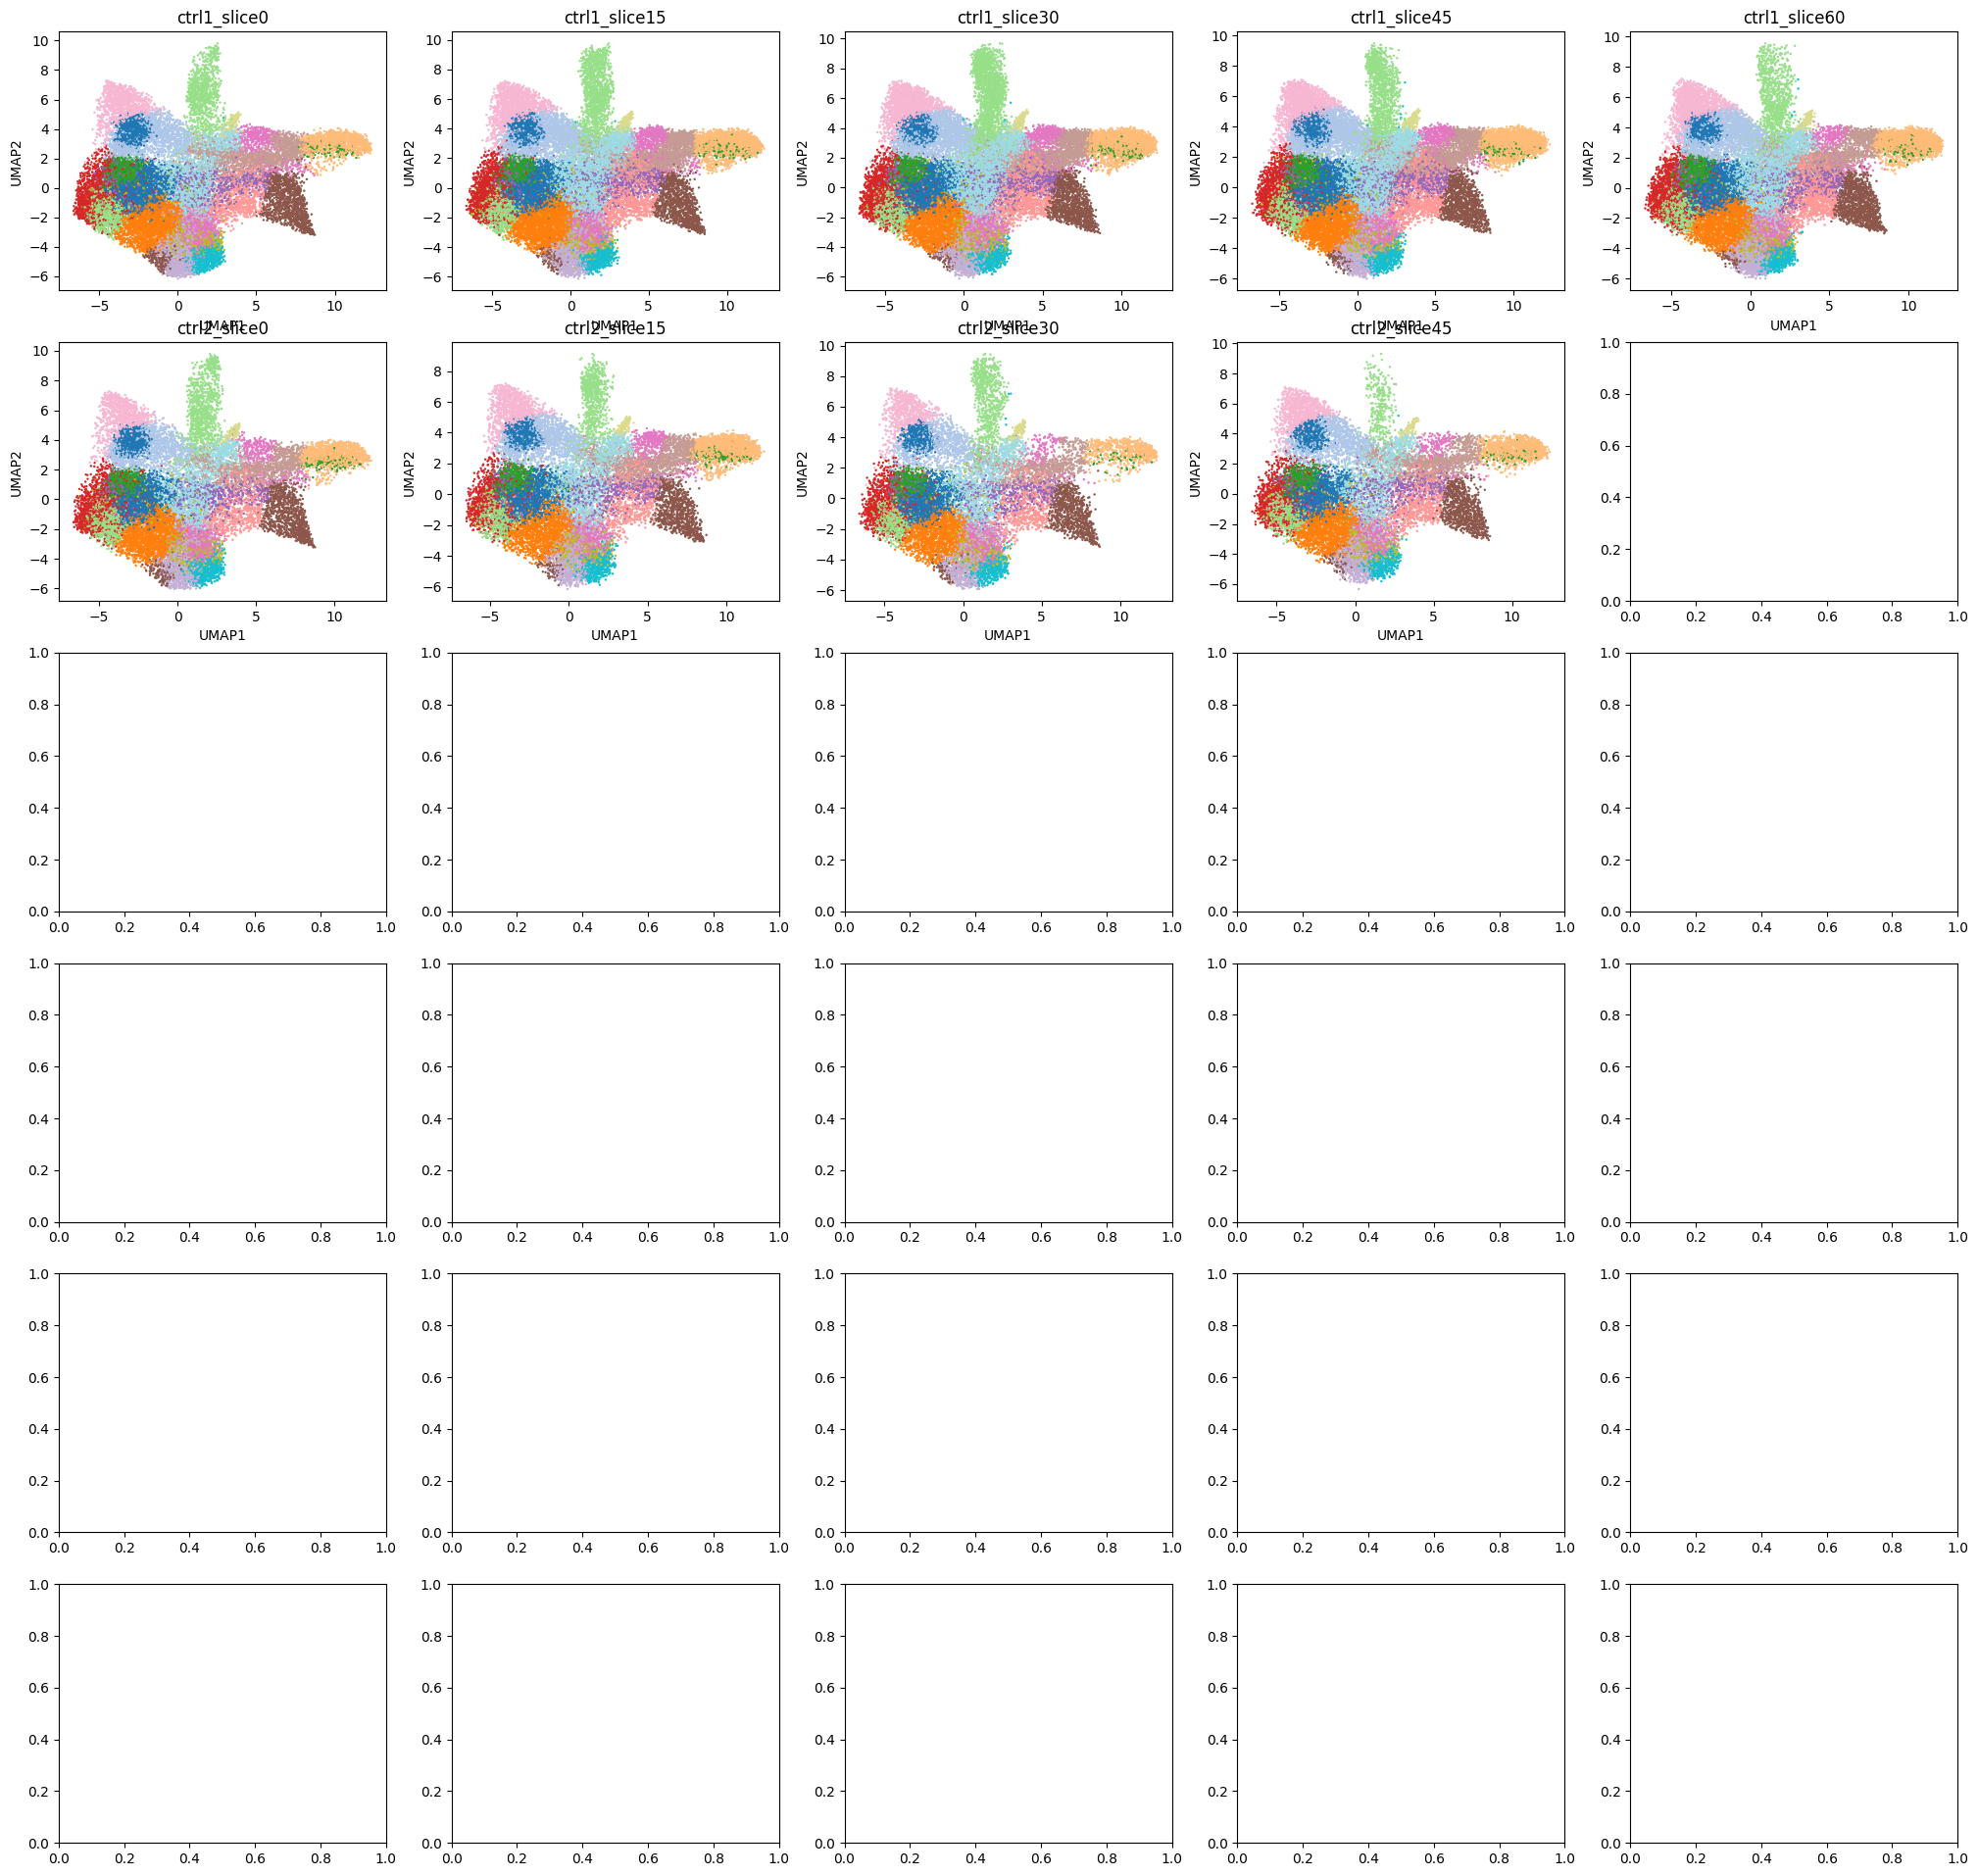

In [17]:
res='1.9-0.5'
# =========================
# 10. UMAP
# =========================
sc.tl.umap(adata, random_state=0)

adata.write(f"{output_path}/adata_harmony_leiden_umap_res{res}.h5ad")

# =========================
# 11. 基础UMAP图
# =========================
sc.pl.umap(
    adata,
    color=["subcluster", "condition", "replicate", "library_id"],
    wspace=0.35,
    legend_loc="right margin",
    size=8,
    show=False
)
plt.savefig(os.path.join(output_path, f"umap_subcluster_condition_batch_res{res}.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# =========================
# 12. 按切片/文库统一颜色画 UMAP 子图
# =========================
cats = adata.obs["subcluster"].cat.categories.tolist()
cmap = plt.get_cmap("tab20", len(cats))
palette = {c: mpl.colors.to_hex(cmap(i)) for i, c in enumerate(cats)}

handles = [
    Line2D([0], [0], marker='o', color='w', label=c,
           markerfacecolor=palette[c], markersize=6)
    for c in cats
]

library_ids = sorted(adata.obs["library_id"].astype(str).unique().tolist())

ncols = 5
nrows = int(np.ceil(len(library_ids) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

umap = adata.obsm["X_umap"]

for ax, lib in zip(axes, library_ids):
    idx = (adata.obs["library_id"].values.astype(str) == lib)
    colors = adata.obs.loc[idx, "subcluster"].map(palette).values
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=3, linewidths=0)
    ax.set_title(lib)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

for ax in axes[len(library_ids):]:
    ax.axis("off")

fig.legend(handles=handles, labels=cats, loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.savefig(os.path.join(output_path, f"umap_by_library_subcluster_res{res}.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# =========================
# 13. 按切片画空间分布图（x, y）
# =========================
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, lib in zip(axes, library_ids):
    idx = (adata.obs["library_id"].values.astype(str) == lib)
    colors = adata.obs.loc[idx, "subcluster"].map(palette).values
    ax.scatter(
        adata.obs.loc[idx, "x"].astype(float),
        adata.obs.loc[idx, "y"].astype(float),
        c=colors,
        s=3,
        linewidths=0
    )
    ax.invert_yaxis()
    ax.set_title(lib)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

for ax in axes[len(library_ids):]:
    ax.axis("off")

fig.legend(handles=handles, labels=cats, loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.savefig(os.path.join(output_path, f"spatial_by_library_subcluster_res{res}.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# 也单独保存每个切片的空间图
for lib in library_ids:
    idx = (adata.obs["library_id"].values.astype(str) == lib)
    colors = adata.obs.loc[idx, "subcluster"].map(palette).values

    plt.figure(figsize=(5, 5))
    plt.scatter(
        adata.obs.loc[idx, "x"].astype(float),
        adata.obs.loc[idx, "y"].astype(float),
        c=colors,
        s=3,
        linewidths=0
    )
    plt.gca().invert_yaxis()
    plt.title(lib)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.savefig(f"{output_path}/spatial_by_slice/{lib}_spatial_subclusters.png",
                dpi=300, bbox_inches="tight")
    plt.close()



In [ ]:
# =========================
# 14. 保存最终meta
# =========================
adata.obs.to_csv(f"{output_path}/final_obs_metadata_subcluster_res1.9-0.5.csv")
print("Done.")

Done.


In [ ]:
adata.obs

,condition,replicate,slice_id,sample,library_id,batch,raw_cell_id,coord_row_index_plus1,source_intensity_csv,source_coord_csv,coord_index_plus1,x,y,tic,n_met_detected,concat_library_id,cluster,subcluster
ctrl1_slice0_Spot 1,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 1,2,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,2,61072.238281,10187.917969,71.940926,209,ctrl1_slice0,6,22
ctrl1_slice0_Spot 2,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 2,3,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,3,61092.238281,10187.917969,96.516036,225,ctrl1_slice0,6,22
ctrl1_slice0_Spot 3,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 3,4,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,4,61112.238281,10187.917969,130.074396,255,ctrl1_slice0,6,22
ctrl1_slice0_Spot 4,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 4,5,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,5,60572.238281,10167.917969,76.021944,203,ctrl1_slice0,6,22
ctrl1_slice0_Spot 5,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 5,6,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,6,60592.238281,10167.917969,82.957327,210,ctrl1_slice0,6,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dn3_slice60_Spot 306207,dn,Rep3,S60,60,dn3_slice60,dn3_slice60,Spot 306207,306207,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,306207,2359.611816,5964.661621,1123.678447,258,dn3_slice60,6,22
dn3_slice60_Spot 306208,dn,Rep3,S60,60,dn3_slice60,dn3_slice60,Spot 306208,306208,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,306208,2379.611816,5964.661621,1013.270245,262,dn3_slice60,6,22
dn3_slice60_Spot 306209,dn,Rep3,S60,60,dn3_slice60,dn3_slice60,Spot 306209,306209,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,306209,2399.611816,5964.661621,676.017845,254,dn3_slice60,6,22
dn3_slice60_Spot 306210,dn,Rep3,S60,60,dn3_slice60,dn3_slice60,Spot 306210,306210,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,306210,2419.611816,5964.661621,657.601784,249,dn3_slice60,6,22


In [18]:
ctrl_merged=pd.read_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_PCA_Harmony_Leiden/ctrlIntensity_merged.csv", sep=";",index_col=0)
dn_merged=pd.read_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_PCA_Harmony_Leiden/dnIntensity_merged.csv", sep=";",index_col=0)

In [19]:
ctrl_cluster = adata.obs.loc[
    adata.obs["library_id"].astype(str).str.startswith("ctrl"),
    "subcluster"
].reset_index(drop=True)

dn_cluster = adata.obs.loc[
    adata.obs["library_id"].astype(str).str.startswith("dn"),
    "subcluster"
].reset_index(drop=True)
if len(ctrl_cluster) != len(ctrl_merged):
    raise ValueError(
        f"ctrl 的 cluster 数量 ({len(ctrl_cluster)}) "
        f"与 ctrl_merged 行数 ({len(ctrl_merged)}) 不一致"
    )

if len(dn_cluster) != len(dn_merged):
    raise ValueError(
        f"dn 的 cluster 数量 ({len(dn_cluster)}) "
        f"与 dn_merged 行数 ({len(dn_merged)}) 不一致"
    )

ctrl_merged.insert(0, "cluster", ctrl_cluster.to_numpy())
dn_merged.insert(0, "cluster", dn_cluster.to_numpy())
print(ctrl_merged.iloc[:5,:5])
print(dn_merged.iloc[:5,:5])

               cluster   57.0346   58.0302   59.0139   67.0191
ctrl1_0_pixel1      22  0.000000  0.000000  0.261729  0.000000
ctrl1_0_pixel2      22  0.000000  0.000000  0.140146  0.414068
ctrl1_0_pixel3      22  0.000000  0.258983  0.000000  0.000000
ctrl1_0_pixel4      22  0.201059  0.000000  0.000000  0.495467
ctrl1_0_pixel5      22  0.577206  0.000000  0.849775  0.000000
             cluster   57.0346   58.0302   59.0139   67.0191
dn1_0_pixel1      22  0.000000  0.712215  0.000000  0.000000
dn1_0_pixel2      22  0.000000  1.836354  3.292773  1.308666
dn1_0_pixel3      22  0.000000  1.547361  0.000000  1.246902
dn1_0_pixel4      22  0.830629  0.540409  0.000000  0.000000
dn1_0_pixel5      22  0.000000  0.000000  0.000000  0.202554


In [20]:
ctrl_mz_cols = [c for c in ctrl_merged.columns if c != "cluster"]
ctrl_mz_cols = sorted(ctrl_mz_cols, key=lambda x: float(x))
ctrl_merged = ctrl_merged[["cluster"] + ctrl_mz_cols]

ctrl_tmp = ctrl_merged.copy()
ctrl_tmp["group"] = ctrl_tmp.index.to_series().str.replace(r"_pixel\d+$", "", regex=True)
ctrl_cluster_mean = ctrl_tmp.groupby(
    ["group", "cluster"],
    sort=False
)[ctrl_mz_cols].mean()
ctrl_cluster_mean.index = [
    f"{group}_cluster{cluster}"
    for group, cluster in ctrl_cluster_mean.index
]
ctrl_sort_df = ctrl_cluster_mean.copy()
ctrl_parts = ctrl_sort_df.index.to_series().str.extract(
    r"^ctrl(\d+)_(\d+)_cluster(\d+)$"
)
ctrl_sort_df["_sample_num"] = ctrl_parts[0].astype(int)
ctrl_sort_df["_time"] = ctrl_parts[1].astype(int)
ctrl_sort_df["_cluster"] = ctrl_parts[2].astype(int)
ctrl_sort_df = ctrl_sort_df.sort_values(
    by=["_sample_num", "_cluster", "_time"],
    kind="stable"
)
ctrl_cluster_mean = ctrl_sort_df.drop(
    columns=["_sample_num", "_time", "_cluster"]
)
print(ctrl_cluster_mean.iloc[:10,:5])

                    57.0346   58.0302   59.0139   67.0191   68.0143
ctrl1_0_cluster0   0.593702  0.930510  3.861469  1.038596  1.946709
ctrl1_15_cluster0  0.709279  1.086151  4.490319  1.160576  1.782847
ctrl1_30_cluster0  0.745009  1.001407  5.046082  1.267908  1.647535
ctrl1_45_cluster0  0.772981  1.043459  5.404636  1.298276  1.508370
ctrl1_60_cluster0  0.812587  1.065167  5.613149  1.413053  1.492730
ctrl1_0_cluster1   0.598431  1.066502  3.947366  1.094350  2.285063
ctrl1_15_cluster1  0.712387  1.138536  4.668010  1.168047  2.008724
ctrl1_30_cluster1  0.711514  1.028820  4.837098  1.203474  1.619537
ctrl1_45_cluster1  0.734162  1.068395  5.368954  1.283526  1.685485
ctrl1_60_cluster1  0.812861  1.084386  5.624434  1.399771  1.631711


In [21]:
dn_mz_cols = [c for c in dn_merged.columns if c != "cluster"]
dn_mz_cols = sorted(dn_mz_cols, key=lambda x: float(x))
dn_merged = dn_merged[["cluster"] + dn_mz_cols]

dn_tmp = dn_merged.copy()
dn_tmp["group"] = dn_tmp.index.to_series().str.replace(r"_pixel\d+$", "", regex=True)
dn_cluster_mean = dn_tmp.groupby(
    ["group", "cluster"],
    sort=False
)[dn_mz_cols].mean()
dn_cluster_mean.index = [
    f"{group}_cluster{cluster}"
    for group, cluster in dn_cluster_mean.index
]
dn_sort_df = dn_cluster_mean.copy()

dn_parts = dn_sort_df.index.to_series().str.extract(
    r"^dn(\d+)_(\d+)_cluster(\d+)$"
)

dn_sort_df["_sample_num"] = dn_parts[0].astype(int)
dn_sort_df["_time"] = dn_parts[1].astype(int)
dn_sort_df["_cluster"] = dn_parts[2].astype(int)

dn_sort_df = dn_sort_df.sort_values(
    by=["_sample_num", "_cluster", "_time"],
    kind="stable"
)

dn_cluster_mean = dn_sort_df.drop(
    columns=["_sample_num", "_time", "_cluster"]
)
print(dn_cluster_mean.iloc[:10,:5])


                  57.0346   58.0302   59.0139   67.0191   68.0143
dn1_0_cluster0   0.677808  0.996218  4.494282  1.114237  2.048159
dn1_15_cluster0  0.739320  1.161521  4.788279  1.258181  1.865791
dn1_30_cluster0  0.806264  1.227139  5.306307  1.360993  1.775912
dn1_45_cluster0  0.809936  1.203339  5.610309  1.547434  1.605859
dn1_60_cluster0  0.738803  1.111511  5.531004  1.550607  1.460465
dn1_0_cluster1   0.698126  1.042838  4.778858  1.167077  2.257517
dn1_15_cluster1  0.766598  1.100295  4.774406  1.248535  1.803400
dn1_30_cluster1  0.858883  1.303232  5.392033  1.391716  1.890143
dn1_45_cluster1  0.866021  1.256584  5.513380  1.513884  1.730507
dn1_60_cluster1  0.778786  1.072376  5.278779  1.466002  1.565228


In [22]:
ctrl_cluster_mean.to_csv(f'{output_path}/ctrlIntensityMeanByCluster.csv')
dn_cluster_mean.to_csv(f'{output_path}/dnIntensityMeanByCluster.csv')

In [23]:
def linreg_stats(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    n = len(x)
    if n < 2:
        return np.nan, np.nan, np.nan, np.nan

    xm = x.mean()
    ym = y.mean()
    dx = x - xm
    dy = y - ym

    varx = np.sum(dx * dx)
    if varx == 0:
        return np.nan, np.nan, np.nan, np.nan

    slope = np.sum(dx * dy) / varx
    intercept = ym - slope * xm

    yhat = slope * x + intercept
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - ym) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    # y=0 时 x 截距：x0 = -b/a；取绝对值
    x0_abs = np.abs(-intercept / slope) if slope != 0 else np.nan
    return slope, intercept, r2, x0_abs

In [24]:
def build_linreg_result(df):
    """
    df 的行名格式：
    ctrl1_0_cluster0 / dn1_15_cluster2 这类
    列名为 m/z
    """
    tmp = df.copy()

    # 解析行名：样本号、时间、cluster
    parts = tmp.index.to_series().str.extract(
        r"^([A-Za-z]+\d+)_(\d+)_cluster(\d+)$"
    )

    tmp["_sample"] = parts[0]
    tmp["_time"] = parts[1].astype(int)
    tmp["_cluster"] = parts[2].astype(int)

    # m/z 列
    mz_cols = [c for c in tmp.columns if c not in ["_sample", "_time", "_cluster"]]
    mz_cols = sorted(mz_cols, key=lambda x: float(x))

    result_rows = []

    # 按 sample + cluster 分组
    for (sample, cluster), sub in tmp.groupby(["_sample", "_cluster"], sort=False):
        sub = sub.sort_values("_time")

        # 这里 x 实际上就是 [0,15,30,45,60]
        x = sub["_time"].to_numpy(dtype=float)

        for mz in mz_cols:
            y = sub[mz].to_numpy(dtype=float)
            slope, intercept, r2, x0_abs = linreg_stats(x, y)

            result_rows.append({
                "sample": sample,
                "mz": float(mz),
                "cluster": int(cluster),
                "slope": slope,
                "intercept": intercept,
                "r2": r2,
                "x0_abs": x0_abs
            })

    result_df = pd.DataFrame(result_rows)

    # 排序：先 sample，再 cluster，再 mz
    parts2 = result_df["sample"].str.extract(r"^([A-Za-z]+)(\d+)$")
    result_df["_prefix"] = parts2[0]
    result_df["_sample_num"] = parts2[1].astype(int)

    result_df = result_df.sort_values(
        by=["_prefix", "_sample_num", "cluster", "mz"],
        kind="stable"
    ).drop(columns=["_prefix", "_sample_num"])

    result_df = result_df.reset_index(drop=True)
    return result_df

In [25]:
ctrl_linreg_result = build_linreg_result(ctrl_cluster_mean)
dn_linreg_result = build_linreg_result(dn_cluster_mean)

print(ctrl_linreg_result.head())
print(dn_linreg_result.head())

  sample       mz  cluster     slope  intercept        r2      x0_abs
0  ctrl1  57.0346        0  0.003343   0.626417  0.903101  187.373636
1  ctrl1  58.0302        0  0.001511   0.980015  0.338369  648.667742
2  ctrl1  59.0139        0  0.029451   3.999595  0.961590  135.804266
3  ctrl1  67.0191        0  0.005911   1.058359  0.971664  179.056661
4  ctrl1  68.0143        0 -0.007883   1.912125  0.949851  242.566155
  sample       mz  cluster     slope  intercept        r2      x0_abs
0    dn1  57.0346        0  0.001284   0.715905  0.306306  557.539794
1    dn1  58.0302        0  0.001816   1.085465  0.221155  597.711723
2    dn1  59.0139        0  0.019303   4.566941  0.889798  236.590377
3    dn1  67.0191        0  0.007747   1.133892  0.950648  146.372507
4    dn1  68.0143        0 -0.009569   2.038301  0.992471  213.015291


In [26]:
ctrl_linreg_result.to_csv(f'{output_path}/ctrl_linreg_result.csv',index=False)
dn_linreg_result.to_csv(f'{output_path}/dn_linreg_result.csv',index=False)

In [27]:
ctrl_r2_mean = (
    ctrl_linreg_result
    .groupby(["sample", "mz"], as_index=False)["r2"]
    .mean()
    .rename(columns={"r2": "mean_r2"})
)

ctrl_good = ctrl_r2_mean[ctrl_r2_mean["mean_r2"] >= 0.9].copy()

# 每个样本筛出来多少个代谢物
ctrl_count = (
    ctrl_good
    .groupby("sample", as_index=False)
    .size()
    .rename(columns={"size": "n_metabolites_r2_ge_0.9"})
)

print("ctrl_good:")
print(ctrl_good.head())

print("ctrl_count:")
print(ctrl_count)


dn_r2_mean = (
    dn_linreg_result
    .groupby(["sample", "mz"], as_index=False)["r2"]
    .mean()
    .rename(columns={"r2": "mean_r2"})
)

dn_good = dn_r2_mean[dn_r2_mean["mean_r2"] >= 0.9].copy()

dn_count = (
    dn_good
    .groupby("sample", as_index=False)
    .size()
    .rename(columns={"size": "n_metabolites_r2_ge_0.9"})
)

print("dn_good:")
print(dn_good.head())

print("dn_count:")
print(dn_count)

ctrl_good:
   sample       mz   mean_r2
2   ctrl1  59.0139  0.912820
14  ctrl1  73.0294  0.911929
15  ctrl1  74.0246  0.920874
35  ctrl1  88.0405  0.966020
37  ctrl1  89.0246  0.974777
ctrl_count:
  sample  n_metabolites_r2_ge_0.9
0  ctrl1                      119
1  ctrl2                       69
2  ctrl3                      169
dn_good:
   sample        mz   mean_r2
34    dn1   88.0405  0.936342
35    dn1   89.0246  0.943041
46    dn1   96.9696  0.924348
76    dn1  110.9758  0.903251
89    dn1  115.0207  0.914793
dn_count:
  sample  n_metabolites_r2_ge_0.9
0    dn1                       52
1    dn2                       89
2    dn3                       73
